# FAIR Dynamic LCIA Demo

This notebook showcases the **FAIR climate-model** path of the [`dynamic_characterization`](https://github.com/brightway-lca/dynamic_characterization) package.

Unlike the per-species impulse-response metrics (`radiative_forcing`, `GWP`, `pGWP`, ...), the FAIR path runs the full [FaIR](https://github.com/OMS-NetZero/FAIR) simple climate-model **ensemble** (the calibrated, constrained AR6 set of 841 members) on top of an SSP background scenario. It returns the **change in radiative forcing (ΔRF, W/m²)** and **change in global mean surface temperature (ΔT, K)** attributable to your inventory, with **ensemble uncertainty (quantiles)** and **per-flow / per-activity attribution**.

Two metrics are added to `characterize()`:

- **`fair_radiative_forcing`** → ΔRF [W/m²]
- **`fair_temperature`** → ΔT [K]

Both return a long `DataFrame` with an extra **`quantile`** column.

## 0. Install

FAIR is an optional dependency:

```console
$ pip install dynamic_characterization[fair]
```

> The calibrated AR6 ensemble is **not** bundled in `fair`; it is downloaded and cached (via `pooch`) on the **first** FAIR run, so the first call needs network access.

## 1. Standalone use (no Brightway required)

The FAIR path only needs a dynamic inventory `DataFrame` that carries a **`flow_name`** column (so flows can be mapped to FAIR emission species) and a **FAIR-capable scenario**. When you use it through Brightway (Section 4) the flow names are filled in automatically.

Let's define a small system: a power plant emitting CO₂ in 2030 and 2035, and a gas leak emitting CH₄ in 2030.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dynamic_inventory_df = pd.DataFrame(
    {
        "date": pd.to_datetime(["2030-01-01", "2035-01-01", "2030-01-01"]),
        "amount": [1e11, 5e10, 2e9],  # kg: 100 Mt CO2, 50 Mt CO2, 2 Mt CH4
        "flow": [1, 1, 2],
        "activity": ["power_plant", "power_plant", "gas_leak"],
        "flow_name": [
            "Carbon dioxide, fossil",
            "Carbon dioxide, fossil",
            "Methane, fossil",
        ],
    }
)
dynamic_inventory_df

,date,amount,flow,activity,flow_name
0,2030-01-01,1.000000e+11,1,power_plant,"Carbon dioxide, fossil"
1,2035-01-01,5.000000e+10,1,power_plant,"Carbon dioxide, fossil"
2,2030-01-01,2.000000e+09,2,gas_leak,"Methane, fossil"


### Choosing a FAIR scenario

FAIR runs against an SSP marker background. Use `available_fair_scenarios()` to list the scenarios that support FAIR metrics. FAIR-native scenarios are set with `set_fair_scenario(ssp, rcp)`; four scenarios also work with the prospective metrics.

In [2]:
from dynamic_characterization import characterize
import dynamic_characterization.prospective as prospective

prospective.available_fair_scenarios()

[('SSP1', '1.9'),
 ('SSP1', '2.6'),
 ('SSP2', '4.5'),
 ('SSP3', '7.0'),
 ('SSP4', '3.4'),
 ('SSP4', '6.0'),
 ('SSP5', '3.4-over'),
 ('SSP5', '8.5')]

In [3]:
# pick a FAIR-native SSP2-4.5 background
prospective.set_fair_scenario("SSP2", "4.5")

### Radiative forcing (ΔRF)

`characterize(..., metric="fair_radiative_forcing")` runs the ensemble and returns one row per `(year, flow, activity, quantile)`. `time_horizon` sets the analysis end as (last emission year + `time_horizon`).

> The first call in a session pays for the FAIR setup (reading the calibration, filling the SSP background, spinning the climate up from 1750). That work is cached, so later calls - other metrics, other inventories, other scenarios - are much faster.

In [4]:
df_rf = characterize(
    dynamic_inventory_df,
    metric="fair_radiative_forcing",
    time_horizon=70,
)
df_rf.head()

,date,amount,flow,activity,quantile
0,2031-01-01,0.000133,1,power_plant,2.5
1,2031-01-01,0.000317,2,gas_leak,2.5
2,2032-01-01,0.000115,1,power_plant,2.5
3,2032-01-01,0.000297,2,gas_leak,2.5
4,2033-01-01,0.000104,1,power_plant,2.5


Each row is the ΔRF attributable to one flow in one year, for one ensemble quantile. Let's plot the **total** ΔRF trajectory (summed over flows) with the ensemble spread (median line, 2.5–97.5th percentile band).

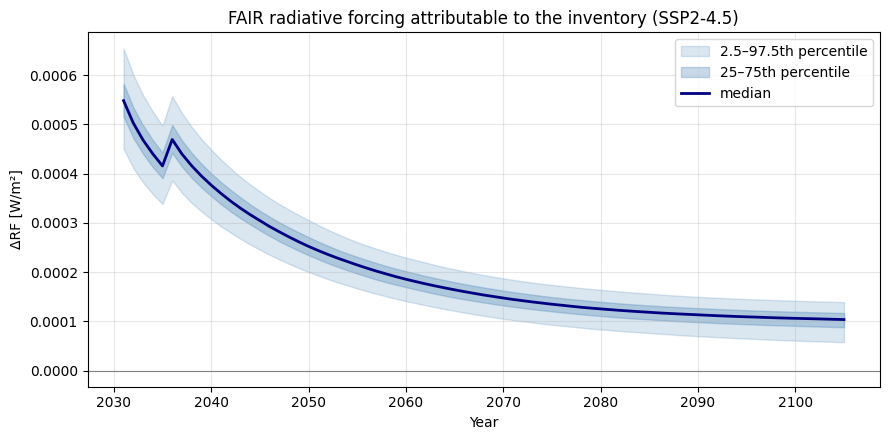

In [5]:
def total_by_quantile(df):
    """Sum the per-flow amount over flows, per (year, quantile)."""
    g = (
        df.assign(year=df["date"].dt.year)
        .groupby(["year", "quantile"])["amount"]
        .sum()
        .unstack("quantile")
    )
    return g


def plot_band(df, ylabel, title):
    g = total_by_quantile(df)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.fill_between(g.index, g[2.5], g[97.5], alpha=0.2, color='steelblue',
                    label='2.5–97.5th percentile')
    ax.fill_between(g.index, g[25.0], g[75.0], alpha=0.3, color='steelblue',
                    label='25–75th percentile')
    ax.plot(g.index, g[50.0], color='navy', lw=2, label='median')
    ax.axhline(0, color='grey', lw=0.8)
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_band(df_rf, 'ΔRF [W/m²]',
          'FAIR radiative forcing attributable to the inventory (SSP2-4.5)')

### Temperature (ΔT)

The same call with `metric="fair_temperature"` returns the temperature anomaly ΔT [K].

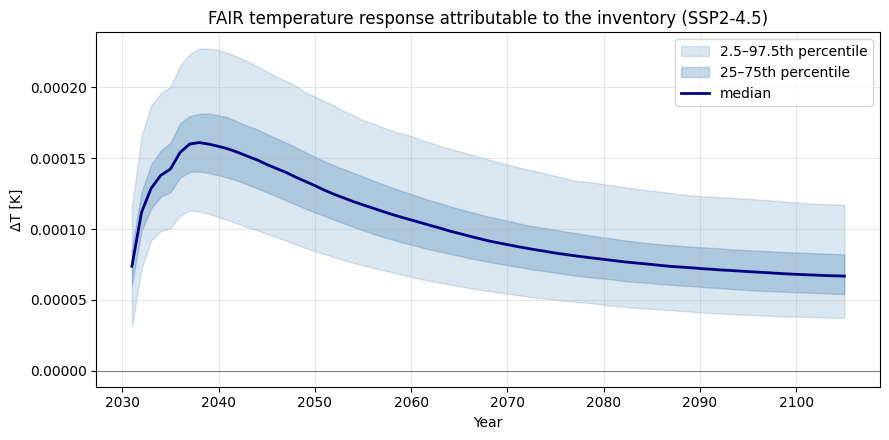

In [6]:
df_temp = characterize(
    dynamic_inventory_df,
    metric="fair_temperature",
    time_horizon=70,
)
plot_band(df_temp, 'ΔT [K]',
          'FAIR temperature response attributable to the inventory (SSP2-4.5)')

### Per-flow / per-activity attribution

Because the result is attributed per flow and activity, we can break the impact down by emitting activity. Here is the median ΔT trajectory for each activity.

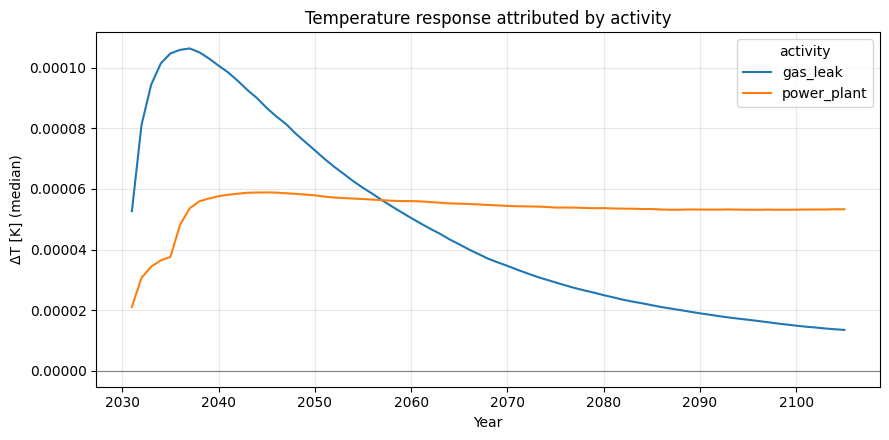

In [7]:
med = df_temp[df_temp['quantile'] == 50.0].copy()
med['year'] = med['date'].dt.year
pivot = med.pivot_table(index='year', columns='activity', values='amount', aggfunc='sum')

fig, ax = plt.subplots(figsize=(9, 4.5))
pivot.plot(ax=ax)
ax.axhline(0, color='grey', lw=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('ΔT [K] (median)')
ax.set_title('Temperature response attributed by activity')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Comparing FAIR background scenarios

The marginal climate response of the *same* inventory depends (slightly, via the nonlinear carbon cycle and climate state) on the SSP background it is added to. Let's compare the median ΔT under a low and a high background pathway. Switching the scenario only refills the marker background; the calibrated ensemble is already set up.

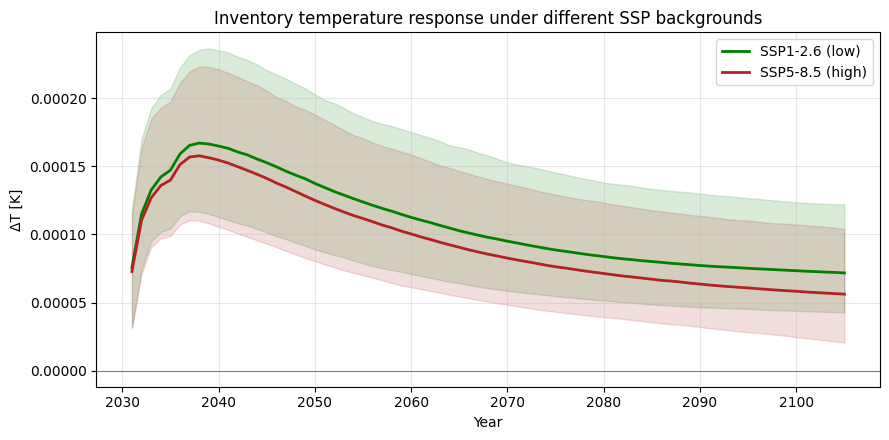

In [8]:
scenarios = [
    (("SSP1", "2.6"), "SSP1-2.6 (low)", "green"),
    (("SSP5", "8.5"), "SSP5-8.5 (high)", "firebrick"),
]

fig, ax = plt.subplots(figsize=(9, 4.5))
for (ssp, rcp), label, color in scenarios:
    prospective.set_fair_scenario(ssp, rcp)
    df = characterize(dynamic_inventory_df, metric='fair_temperature', time_horizon=70)
    g = total_by_quantile(df)
    ax.plot(g.index, g[50.0], color=color, lw=2, label=label)
    ax.fill_between(g.index, g[2.5], g[97.5], alpha=0.15, color=color)

ax.axhline(0, color='grey', lw=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('ΔT [K]')
ax.set_title('Inventory temperature response under different SSP backgrounds')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. A realistic inventory: time-explicit LCA with `bw_timex`

The inventories above were toy examples. A real dynamic inventory has hundreds of thousands of rows, and it usually comes out of a temporal LCA. Here we take the [electric vehicle case study](https://docs.brightway.dev/projects/bw-timex/en/latest/content/examples/electric_vehicle_premise.html) from [`bw_timex`](https://github.com/brightway-lca/bw_timex): a cradle-to-grave ev, driven for 150,000 km over 15 years, with prospective background databases (ecoinvent 3.12 + [`premise`](https://github.com/polca/premise), REMIND-EU SSP2-NDC for 2020/2030/2040).

> **Prerequisites:** this section needs the brightway project of that case study (`ei312_REMIND_EU`, with the `foreground` and `ev_background_<year>` databases it builds) and `bw_timex` installed. Everything `bw_timex`-specific is in the next cell; the FAIR part afterwards only ever sees the resulting `dynamic_inventory_df`.

In [9]:
import bw2data as bd
from bw_timex import TimexLCA

bd.projects.set_current("ei312_REMIND_EU")

driving = bd.get_node(database="foreground", name="driving an electric vehicle")
method = ("ecoinvent-3.12", "EF v3.1", "climate change", "global warming potential (GWP100)")

tlca = TimexLCA({driving: 1}, method)  # 1 ev lifetime
tlca.build_timeline(temporal_grouping="month", graph_traversal="bfs")
tlca.lci()

2026-09-20 11:23:56.001 | INFO     | bw_timex.timex_lca:__init__:445 - Initializing TimexLCA object...


2026-09-20 11:23:56.002 | INFO     | bw_timex.timex_lca:__init__:534 - Calculating base LCA...


2026-09-20 11:23:56.455 | INFO     | bw_timex.timex_lca:__init__:591 - Collecting node infos...


2026-09-20 11:23:56.498 | INFO     | bw_timex.timex_lca:__init__:606 - Loading node metadata from 10 database(s)...


2026-09-20 11:24:06.110 | INFO     | bw_timex.timex_lca:__init__:674 - TimexLCA initialized.


...

2026-09-20 11:24:06.167 | INFO     | bw_timex.timex_lca:build_timeline:1309 - Creating activity time mapping...


2026-09-20 11:24:06.349 | INFO     | bw_timex.timeline_builder:__init__:120 - Traversing supply chain graph...


2026-09-20 11:24:06.369 | INFO     | bw_timex.timeline_builder:build_timeline:191 - Building timeline...


2026-09-20 11:24:07.068 | INFO     | bw_timex.timex_lca:lci:1475 - Expanding matrices...


2026-09-20 11:24:07.097 | INFO     | bw_timex.timex_lca:lci:1494 - Calculating dynamic inventory...


That's it for the time-explicit part. What we want from it is the **dynamic inventory**: which biosphere flow is emitted, by which (time-mapped) activity, and when.

In [10]:
dynamic_inventory_df = tlca.dynamic_inventory_df

print(f"{len(dynamic_inventory_df):,} rows | "
      f"{dynamic_inventory_df['flow'].nunique():,} biosphere flows | "
      f"{dynamic_inventory_df['activity'].nunique()} activities | "
      f"{dynamic_inventory_df['date'].min():%Y-%m} to {dynamic_inventory_df['date'].max():%Y-%m}")
dynamic_inventory_df.head()

80,942 rows | 2,794 biosphere flows | 29 activities | 2024-07 to 2043-01


,date,amount,flow,activity
603,2024-07-01,19606.103013,267655083917308008,358849921536319489
2215,2024-07-01,5637.324521,267655084743585810,358849921536319489
1342,2024-07-01,3241.784529,267655084294795269,358849921536319489
267,2024-07-01,3214.327586,267655083611123782,358849921536319489
68,2024-07-01,2272.096381,267655083426574452,358849921536319489


This frame goes straight into `characterize()`. The biosphere flow names are looked up automatically from the `flow` ids, so no `flow_name` column is needed here.

In [11]:
import time

prospective.set_fair_scenario("SSP2", "4.5")

start = time.perf_counter()
df_ev_temp = characterize(
    dynamic_inventory_df,
    metric="fair_temperature",
    time_horizon=50,
)
print(f"{time.perf_counter() - start:.1f} s for {len(df_ev_temp):,} characterized rows")
df_ev_temp.head()

2026-09-20 11:24:11.614 | INFO     | dynamic_characterization.fair.core:_warn_about_unmapped:76 - FAIR characterization skipped 987 of 1031 inventory flows that no species in the map covers, 1.066e+06 kg in total. Largest: Radon-222 (4.148e+05 kg), Noble gases, radioactive, unspecified (1.09e+05 kg), Water (1.082e+05 kg), Water, turbine use, unspecified natural origin (1.074e+05 kg), Energy, kinetic (in wind), converted (7.207e+04 kg).


16.1 s for 981,008 characterized rows


,date,amount,flow,activity,quantile
0,2025-01-01,6.643008e-17,267655083426574370,358849921536319489,2.5
1,2025-01-01,2.647214e-16,267655083426574370,358849921536319490,2.5
2,2025-01-01,8.742995e-17,267655083426574370,358849921536319493,2.5
3,2025-01-01,3.342742e-17,267655083426574370,358849921536319492,2.5
4,2025-01-01,9.044065e-18,267655083426574370,358849921536319491,2.5


The cost of a FAIR characterization is driven by the number of **species** in the inventory (one perturbation run each), not by the number of inventory rows. Both outputs come from the same cached runs, so asking for radiative forcing afterwards is essentially free:

In [12]:
start = time.perf_counter()
df_ev_rf = characterize(
    dynamic_inventory_df,
    metric="fair_radiative_forcing",
    time_horizon=50,
)
print(f"{time.perf_counter() - start:.1f} s (reuses the cached FAIR runs)")

2026-09-20 11:24:27.723 | INFO     | dynamic_characterization.fair.core:_warn_about_unmapped:76 - FAIR characterization skipped 987 of 1031 inventory flows that no species in the map covers, 1.066e+06 kg in total. Largest: Radon-222 (4.148e+05 kg), Noble gases, radioactive, unspecified (1.09e+05 kg), Water (1.082e+05 kg), Water, turbine use, unspecified natural origin (1.074e+05 kg), Energy, kinetic (in wind), converted (7.207e+04 kg).


0.5 s (reuses the cached FAIR runs)


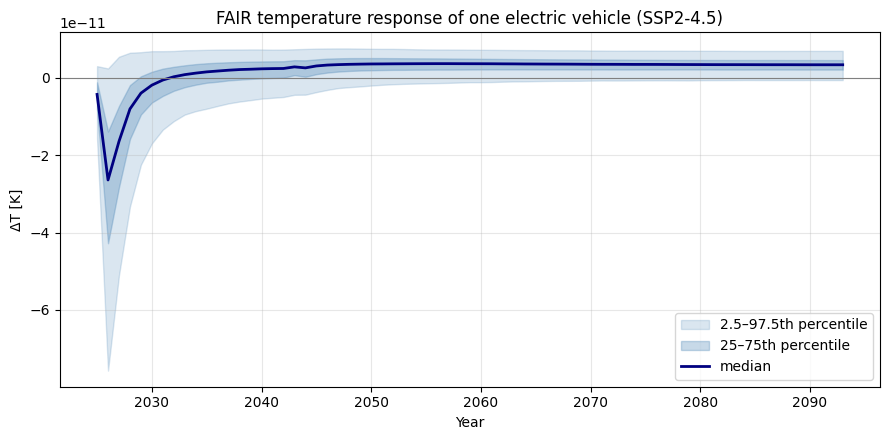

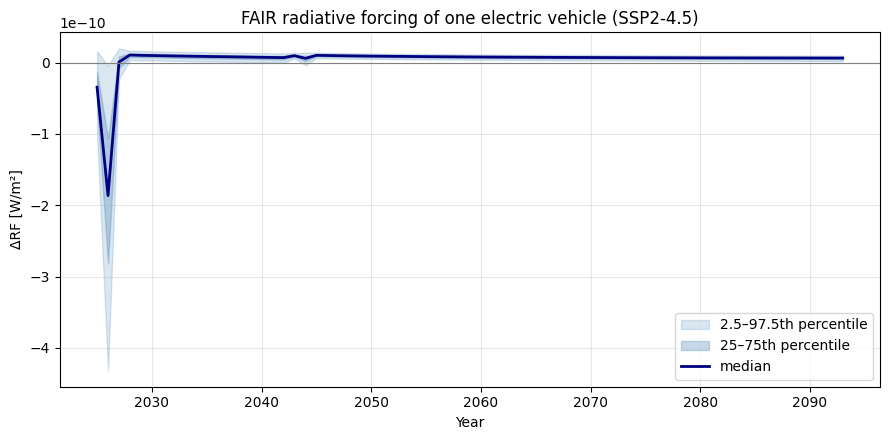

In [13]:
plot_band(df_ev_temp, 'ΔT [K]',
          'FAIR temperature response of one electric vehicle (SSP2-4.5)')
plot_band(df_ev_rf, 'ΔRF [W/m²]',
          'FAIR radiative forcing of one electric vehicle (SSP2-4.5)')

The curve dips sharply negative before it settles: that is the **aerosol cooling** from the sulfur dioxide co-emitted while the car is built, which is strong but short-lived, while the CO₂ warming is small but permanent. This is a feature of running an actual climate model: per-species GWP-style characterization only sees the greenhouse gases. The masses behind it:

In [14]:
from dynamic_characterization.fair.species_map import resolve_species

flow_names = {f: bd.get_node(id=f)['name'] for f in dynamic_inventory_df['flow'].unique()}
species = dynamic_inventory_df['flow'].map(lambda f: resolve_species(flow_names[f])[0])

(dynamic_inventory_df.assign(species=species)
     .dropna(subset=['species'])
     .groupby('species')['amount'].sum()
     .sort_values(ascending=False)
     .rename('kg over the life cycle')
     .to_frame())

,kg over the life cycle
species,
CO2 FFI,9.556969e+03
CO2 AFOLU,5.318882e+03
Sulfur,5.638131e+01
CO,3.232460e+01
CH4,2.634705e+01
NOx,2.294711e+01
VOC,1.328167e+01
NH3,1.430627e+00
N2O,4.027719e-01


And the per-activity attribution, with the time-mapped activity ids resolved back to names by `bw_timex`:

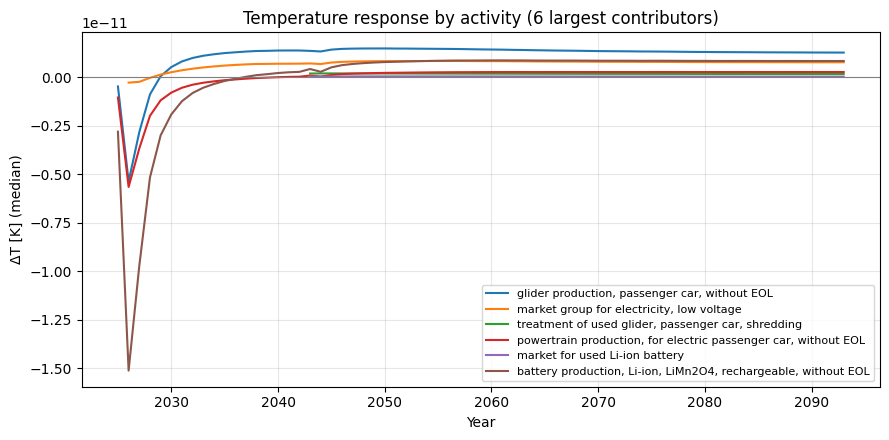

In [15]:
med = df_ev_temp[df_ev_temp['quantile'] == 50.0].copy()
med['year'] = med['date'].dt.year
med['activity_name'] = med['activity'].map(
    {a: tlca.get_activity_name_from_time_mapped_id(a) for a in med['activity'].unique()}
)

pivot = med.pivot_table(index='year', columns='activity_name', values='amount', aggfunc='sum')
top = pivot.sum().abs().sort_values(ascending=False).head(6).index
pivot = pivot[top]

fig, ax = plt.subplots(figsize=(9, 4.5))
pivot.plot(ax=ax)
ax.axhline(0, color='grey', lw=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('ΔT [K] (median)')
ax.set_title('Temperature response by activity (6 largest contributors)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()